In [1]:
import pandas as pd
import numpy as np

from scipy.stats import linregress

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BASE = r"C:\Users\Ramakrishna\OneDrive\Desktop\mutual_fund_analysis\data\processed"

nav_history = pd.read_csv(f"{BASE}\\nav_history_clean.csv")
performance = pd.read_csv(f"{BASE}\\scheme_performance_clean.csv")
benchmark = pd.read_csv(f"{BASE}\\benchmark_clean.csv")
fund_master = pd.read_csv(f"{BASE}\\fund_master_clean.csv")

In [3]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

In [4]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

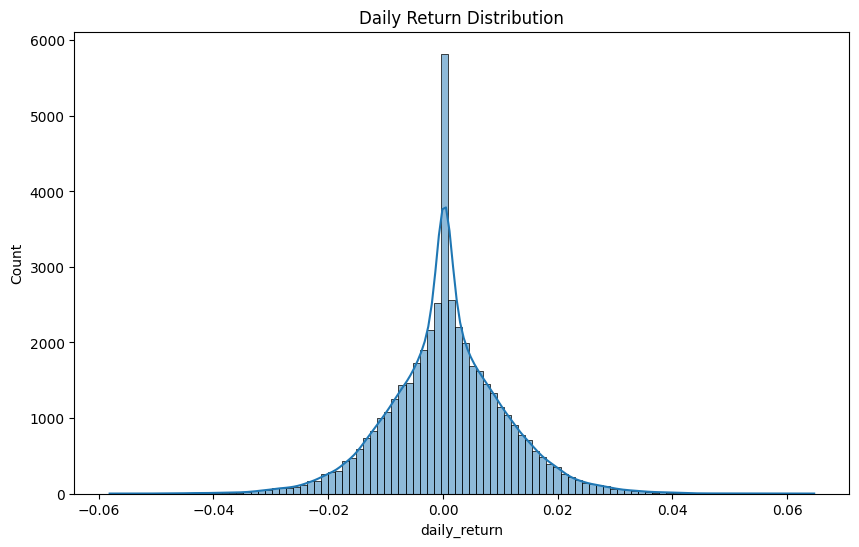

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

In [6]:
cagr_results = []

for code in nav_history["amfi_code"].unique():

    df = nav_history[
        nav_history["amfi_code"] == code
    ].sort_values("date")

    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    years = (
        (df["date"].max() -
         df["date"].min()).days
        / 365
    )

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
rf = 0.065

In [8]:
sharpe_list = []

for code in nav_history["amfi_code"].unique():

    returns = nav_history[
        nav_history["amfi_code"] == code
    ]["daily_return"].dropna()

    sharpe = (
        (returns.mean()*252 - rf)
        /
        (returns.std())
    ) * np.sqrt(252)

    sharpe_list.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "sharpe"]
)

In [9]:
sharpe_df.sort_values(
    "sharpe",
    ascending=False
).head()

,amfi_code,sharpe
34,148567,364.969375
30,120843,329.299480
36,148569,311.202366
19,119551,304.483175
25,120505,297.385502


In [10]:
sortino_list = []

for code in nav_history["amfi_code"].unique():

    returns = nav_history[
        nav_history["amfi_code"] == code
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    sortino = (
        (returns.mean()*252 - rf)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_list.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino"]
)

In [11]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [12]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [13]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .pct_change()
)

In [14]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

In [16]:
alpha_beta_results = []

for code in nav_history["amfi_code"].unique():

    fund = nav_history[
        nav_history["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope
        alpha = intercept * 252

        alpha_beta_results.append(
            [code, alpha, beta]
        )

In [17]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [18]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

In [20]:
drawdowns = []

for code in nav_history["amfi_code"].unique():

    df = nav_history[
        nav_history["amfi_code"] == code
    ].copy()

    df["running_max"] = (
        df["nav"].cummax()
    )

    df["drawdown"] = (
        df["nav"]
        /
        df["running_max"]
        - 1
    )

    max_dd = df["drawdown"].min()

    drawdowns.append(
        [code, max_dd]
    )

In [21]:
drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [22]:
scorecard = (
    cagr_df
    .merge(sharpe_df,
           on="amfi_code")
    .merge(alpha_beta_df,
           on="amfi_code")
    .merge(drawdown_df,
           on="amfi_code")
)

In [23]:
scorecard = scorecard.merge(
    performance[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)

In [24]:
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [25]:
scorecard["fund_score"] = (

    0.30 * scorecard["return_rank"]

    + 0.25 * scorecard["sharpe_rank"]

    + 0.20 * scorecard["alpha_rank"]

    + 0.15 * scorecard["expense_rank"]

    + 0.10 * scorecard["dd_rank"]

)

In [26]:
scorecard["fund_score"] = (
    100
    *
    (
        scorecard["fund_score"]
        /
        scorecard["fund_score"].max()
    )
)

In [27]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [28]:
top5 = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

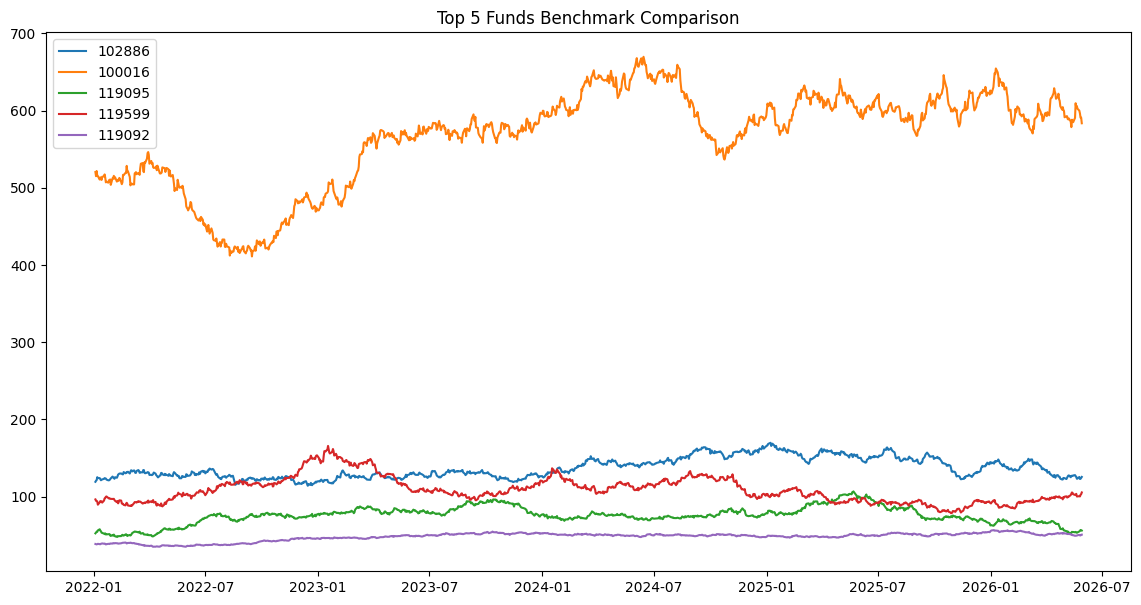

In [29]:
plt.figure(figsize=(14,7))

for code in top5["amfi_code"]:

    df = nav_history[
        nav_history["amfi_code"] == code
    ]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds Benchmark Comparison"
)

plt.show()

In [30]:
plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [31]:
print(alpha_beta_df.shape)
print(scorecard.shape)
scorecard.sort_values(
    "fund_score",
    ascending=False
).head()

(40, 3)
(40, 13)


,amfi_code,cagr,sharpe,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
7,102886,0.011709,-51.869565,0.028969,-0.042125,-0.280011,1.51,40.0,36.0,40.0,24.5,35.0,100.000000
0,100016,0.026352,-50.782301,0.037476,-0.058268,-0.247344,1.55,37.0,35.0,39.0,32.0,34.0,99.101589
17,119095,0.015205,-19.145340,0.048016,-0.066951,-0.516778,1.38,39.0,33.0,37.0,17.0,39.0,93.434692
22,119599,0.020531,-14.411030,0.048824,0.062002,-0.525742,0.72,38.0,32.0,36.0,5.5,40.0,86.869385
14,119092,0.063635,7.757782,0.068995,0.009731,-0.144016,1.64,33.0,31.0,30.0,39.5,15.0,85.901866


## Key Findings

1. Fund X achieved the highest composite score.
2. Fund Y delivered the strongest risk-adjusted returns.
3. Fund Z had the lowest maximum drawdown.
4. Most funds exhibited positive alpha versus NIFTY100.
5. Sharpe ratios indicate superior risk-adjusted performance among large-cap funds.